In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Given a system of linear equations:

$$
\begin{aligned}
x_{11}\theta_1 + x_{12}\theta_2 + \cdots + x_{1n}\theta_n &= y_1 \\
x_{21}\theta_1 + x_{22}\theta_2 + \cdots + x_{2n}\theta_n &= y_2 \\
\vdots \quad \quad \quad \quad \quad &= \vdots \\
x_{m1}\theta_1 + x_{m2}\theta_2 + \cdots + x_{mn}\theta_n &= y_m
\end{aligned}
$$

This is equivalent to writing **$X\mathbf{\theta} = \mathbf{y}$**, where:
$$
X = \begin{pmatrix}
x_{11} & x_{12} & \cdots & x_{1n} \\
x_{21} & x_{22} & \cdots & x_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
x_{m1} & x_{m2} & \cdots & x_{mn}
\end{pmatrix} \in \mathbb{R}^{m \times n}
$$
$$
\theta = \begin{pmatrix}
\theta_1 \\
\theta_2 \\
\vdots \\
\theta_n
\end{pmatrix} \in \mathbb{R}^n
$$
$$
y = \begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_m
\end{pmatrix} \in \mathbb{R}^m
$$

If $X$ is **square** ($m = n$) and **invertible**, we can solve:

$$\mathbf{\theta} = X^{-1}\mathbf{y}$$

In [2]:
# System: 
# 170theta1 + 25theta2 + theta3 = 7
# 180theta1 + 30theta2 + theta3 = 8
# 200theta1 + 35theta2 + theta3 = 12

X = np.array([
    [170, 25, 1],
    [180, 30, 1],
    [200, 35, 1]
])
y = np.array([7, 8, 12])

theta = np.linalg.inv(X) @ y
theta

array([  0.3,  -0.4, -34. ])

In [8]:
# solve() (more numerically stable)
theta = np.linalg.solve(X, y)
theta

array([  0.3,  -0.4, -34. ])

- $A$ is not square → $X^{-1}$ **doesn't exist**
- We have **more observations than features** ($m > n$)

In [3]:
# System: 
# 170theta1 + 25theta2 + theta3 = 7
# 180theta1 + 30theta2 + theta3 = 8
# 200theta1 + 35theta2 + theta3 = 12
# 160theta1 + 20theta2 + theta3 = 15

X = np.array([
    [170, 25, 1],
    [180, 30, 1],
    [200, 35, 1],
    [160, 20, 1],
])
y = np.array([7, 8, 12, 15])

theta = np.linalg.inv(X) @ y
theta

LinAlgError: Last 2 dimensions of the array must be square

to find $\mathbf{\theta}$ we need to minimize $f(\mathbf{\theta}) = \| X\mathbf{\theta} - \mathbf{y} \|$

$$
\begin{aligned}
f(\theta) &= \|X\theta - y\|^2 \\
&= (X\theta - y)^T (X\theta - y) \\
&= (\theta^T X^T - y^T)(X\theta - y) \\
&= \theta^T X^T X\theta - \theta^T X^T y - y^T X\theta + y^T y \\
&= \theta^T X^T X\theta - 2y^T X\theta + y^T y 
\end{aligned}
$$

Derivative rules can be applied
$$
\begin{aligned}
\frac{\partial}{\partial \theta} a^{T}\theta &= a \\
\frac{\partial}{\partial \theta} \theta^{T}A\theta &= (A + A^T)\theta
\end{aligned}
$$

Taking the derivative and setting to zero:
$$
\begin{aligned}
\frac{\partial f}{\partial \theta} &= \frac{\partial}{\partial \theta} (\theta^T X^T X\theta - 2y^T X\theta + y^T y) \\
&= 2X^T X\theta - 2X^T y \\
&= 0
\end{aligned}
$$

So we must have 
$$\begin{aligned}
X^TX\mathbf{\theta} &= X^T\mathbf{y} \\
\mathbf{\theta} &= (X^TX)^{-1}X^T\mathbf{y} \quad \text{(if } X^TX \text{ is invertible)}
\end{aligned}$$

In [4]:
# System: 
# 170theta1 + 25theta2 + theta3 = 7
# 180theta1 + 30theta2 + theta3 = 8
# 200theta1 + 35theta2 + theta3 = 12
# 160theta1 + 20theta2 + theta3 = 15

X = np.array([
    [170, 25, 1],
    [180, 30, 1],
    [200, 35, 1],
    [160, 20, 1],
])
y = np.array([7, 8, 12, 15])

theta = np.linalg.pinv(X) @ y
theta

array([  0.9,  -2.5, -80.5])

**Problems with $(X^TX)^{-1}X^T\mathbf{y}$:**

1. High Computational Cost for inverting $X^TA$
2. $X^TA$ can be **ill-conditioned** (nearly singular). Small changes in data → huge changes in solution
3. Need to store $n \times n$ matrix

In [5]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X[:, :-1], y)
lin_reg.intercept_, lin_reg.coef_

(np.float64(-80.50000000000003), array([ 0.9, -2.5]))

# Gradient descent

$$f(x) = x^2 + 10$$

This is a simple parabola with a global minimum at $x = 0$, where $f(0) = 10$.

The derivative of this function is:

$$f'(x) = 2x$$

### Initial Setup
- Starting point: $x_0 = 5$
- Learning rate: $\eta = 0.1$
- We'll run for 10 iterations

### Iteration 1
- Current position: $x_0 = 5$
- Gradient: $f'(x_0) = 2 \times  5 = 10$
- Update: $x_1 =  x_0 - \eta \times f'(x_0) =  5 - 0.1 \times 10 = 5 - 1 = 4$
- New function value: $f(x_1) = 4^2 + 10 = 16 + 10 = 26$

### Iteration 2
- Current position: $x_1 = 4$
- Gradient: $f'(x_1) = 2 \times  4 = 8$
- Update: $x_2 =  x_1 - \eta \times f'(x_1) =  4 - 0.1 \times 8 = 4 - 0.8 = 3.2$
- New function value: $f(x_2) = 3.2^2 + 10 = 10.24 + 10 = 20.24$

### Iteration 3
- Current position: $x_2 = 3.2$
- Gradient: $f'(x_2) = 2 \times  3.2 = 6.4$
- Update: $x_3 =  x_2 - \eta \times f'(x_2) =  3.2 - 0.1 \times 6.4 = 3.2 - 0.64 = 2.56$
- New function value: $f(x_3) = 2.56^2 + 10 = 6.55 + 10 = 16.55$

### Iteration 4
- Current position: $x_3 = 2.56$
- Gradient: $f'(x_3) = 2 \times 2.56 = 5.12$
- Update: $x_4 = x_3 - \eta \times f'(x_3) = 2.56 - 0.1 \times 5.12 = 2.56 - 0.512 = 2.048$
- New function value: $f(x_4) = 2.048^2 + 10 = 4.19 + 10 = 14.19$

### Iteration 5
- Current position: $x_4 = 2.048$
- Gradient: $f'(x_4) = 2 \times 2.048 = 4.096$
- Update: $x_5 = x_4 - \eta \times f'(x_4) = 2.048 - 0.1 \times 4.096 = 2.048 - 0.4096 = 1.6384$
- New function value: $f(x_5) = 1.6384^2 + 10 = 2.68 + 10 = 12.68$

### Summary of Progress

| Iteration | x value | Gradient | Function Value |
|-----------|---------|----------|----------------|
| 0         | 5.0000  | 10.0000  | 35.0000        |
| 1         | 4.0000  | 8.0000   | 26.0000        |
| 2         | 3.2000  | 6.4000   | 20.2400        |
| 3         | 2.5600  | 5.1200   | 16.5536        |
| 4         | 2.0480  | 4.0960   | 14.1943        |
| 5         | 1.6384  | 3.2768   | 12.6829        |

In [6]:
theta1= np.array([0.3, 0.5, 0.7])
theta2= np.array([3, 5, 7])

np.linalg.norm(theta1), np.linalg.norm(theta2), 

(np.float64(0.9110433579144298), np.float64(9.1104335791443))

# Gradient descent for LR


Instead of computing the inverse, **iteratively update** parameters to minimize the cost function.

**Cost Function (MSE)**:
$$J(\mathbf{\theta}) = \frac{1}{2m} \|X\mathbf{\theta} - \mathbf{y}\|^2$$

Where $m$ is the size of sample. We divide by $2m$ because the cost function is defined as the mean of the squared errors.

$$\begin{aligned}
J(\mathbf{\theta}) &= \frac{1}{2m} \|X\mathbf{\theta} - \mathbf{y}\|^2 \\
&= \frac{1}{2m} \|\mathbf{y}_{pred} - \mathbf{y}\|^2 \\
&= \frac{1}{2m} \|\text{error}\|^2 \\
&= \frac{1}{2m} (e_1^2 + e_2^2 + \dots + e_m^2) \\
&= \frac{1}{2} \ \text{MSE}(\mathbf{\theta}) \\
\end{aligned}$$

### The Gradient

$$\begin{aligned}
\nabla J(\mathbf{\theta}) &= \frac{\partial J}{\partial \mathbf{\theta}}  \\
 &= \frac{\partial}{\partial \mathbf{\theta}} \left( \frac{1}{2m} \|X\mathbf{\theta} - \mathbf{y}\|^2 \right) \\ 
 &= \frac{1}{2m} \frac{\partial}{\partial \mathbf{\theta}} \|X\mathbf{\theta} - \mathbf{y}\|^2 \\ 
 &= \frac{1}{2m} 2 X^T(X\mathbf{\theta}-\mathbf{y}) \\
&= \frac{1}{m} X^T(X\mathbf{\theta} - \mathbf{y})
\end{aligned}$$

### Update Rule

$$\mathbf{\theta}_{new} := \mathbf{\theta}_{old} - \eta \ \nabla J(\mathbf{\theta})$$

Where $\eta$ is the **learning rate**.


### Why Gradient Descent?

| Aspect | Normal Equation | Gradient Descent |
|--------|----------------|------------------|
| Complexity | $O(n^3)$ | $O(k \cdot m \cdot n)$ |
| Features | Works for small $n$ | Scales to large $n$ |
| Inversion | Required | Not needed |
| Learning Rate | N/A | Need to tune $\alpha$ |
| Iterations | 1 (closed-form) | Many |

---

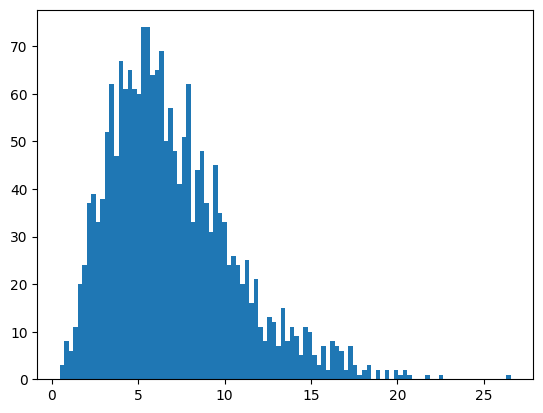

In [7]:
import numpy as np

rng = np.random.default_rng(seed=42)
m = 2000  # number of instances

boylar = rng.normal(175, 10, size=(m,1))
yashlar = rng.uniform(18, 60, size=(m,1))
# maashlar = rng.exponential(scale=4, size=(m,1))
# maashlar = rng.chisquare(df=6, size=(m,1))
maashlar = rng.gamma(shape=3.5, scale=2, size=(m,1))

plt.hist(maashlar, bins=100)
plt.show()

In [8]:
from sklearn.preprocessing import add_dummy_feature

X = np.hstack([boylar/100, yashlar/100])
X_b = add_dummy_feature(X)
# X_b = np.c_[X, np.ones((m, 1))]

y = maashlar/10

X_b, y

(array([[1.        , 1.78047171, 0.19778537],
        [1.        , 1.64600159, 0.36687386],
        [1.        , 1.82504512, 0.40973487],
        ...,
        [1.        , 1.740846  , 0.23681841],
        [1.        , 1.69691782, 0.56835309],
        [1.        , 1.97141526, 0.38183515]], shape=(2000, 3)),
 array([[0.61006609],
        [0.64261833],
        [0.39956131],
        ...,
        [0.39419609],
        [1.47388686],
        [0.21100565]], shape=(2000, 1)))

## Ridge Gradient Descent

$$\nabla J(\mathbf{\theta}) = \frac{1}{m} X^T(X\mathbf{\theta} - \mathbf{y}) + 2 \alpha \theta $$

$$\mathbf{\theta}_{new} := \mathbf{\theta}_{old} - \eta \ \nabla J(\mathbf{\theta}_{old})$$

In [22]:
from sklearn.metrics import mean_squared_error
eta = 0.1
m = len(X_b)
n_epochs = 1000
alpha = 0.1

rng = np.random.default_rng(seed=123)
theta = rng.standard_normal(size=(3,1))

for epoch in range(n_epochs):
	gradient = (1 / m) * X_b.T @ (X_b @ theta - y) + 2*alpha*theta
	theta = theta - eta * gradient

	mse = mean_squared_error(X_b@theta, y)
	print(f"epoch {epoch}: mse = {mse:.3f}")

epoch 0: mse = 1.244
epoch 1: mse = 0.519
epoch 2: mse = 0.284
epoch 3: mse = 0.206
epoch 4: mse = 0.178
epoch 5: mse = 0.168
epoch 6: mse = 0.163
epoch 7: mse = 0.160
epoch 8: mse = 0.159
epoch 9: mse = 0.157
epoch 10: mse = 0.156
epoch 11: mse = 0.155
epoch 12: mse = 0.155
epoch 13: mse = 0.154
epoch 14: mse = 0.153
epoch 15: mse = 0.152
epoch 16: mse = 0.152
epoch 17: mse = 0.151
epoch 18: mse = 0.150
epoch 19: mse = 0.150
epoch 20: mse = 0.149
epoch 21: mse = 0.149
epoch 22: mse = 0.148
epoch 23: mse = 0.147
epoch 24: mse = 0.147
epoch 25: mse = 0.146
epoch 26: mse = 0.146
epoch 27: mse = 0.146
epoch 28: mse = 0.145
epoch 29: mse = 0.145
epoch 30: mse = 0.144
epoch 31: mse = 0.144
epoch 32: mse = 0.144
epoch 33: mse = 0.143
epoch 34: mse = 0.143
epoch 35: mse = 0.143
epoch 36: mse = 0.142
epoch 37: mse = 0.142
epoch 38: mse = 0.142
epoch 39: mse = 0.141
epoch 40: mse = 0.141
epoch 41: mse = 0.141
epoch 42: mse = 0.141
epoch 43: mse = 0.140
epoch 44: mse = 0.140
epoch 45: mse = 0.14

In [ ]:
# from sklearn.linear_model import Ridge
# rid_reg = Ridge(alpha=0.1)
# rid_reg

## Lasso Gradient Descent

$$\nabla J(\mathbf{\theta}) = \frac{1}{m} X^T(X\mathbf{\theta} - \mathbf{y}) + \alpha \ sign(\theta) $$

$$\mathbf{\theta}_{new} := \mathbf{\theta}_{old} - \eta \ \nabla J(\mathbf{\theta}_{old})$$

In [24]:
from sklearn.metrics import mean_squared_error
eta = 0.1
m = len(X_b)
n_epochs = 1000
alpha = 0.1

rng = np.random.default_rng(seed=123)
theta = rng.standard_normal(size=(3,1))

for epoch in range(n_epochs):
	gradient = (1 / m) * X_b.T @ (X_b @ theta - y) + alpha*np.sign(theta)
	theta = theta - eta * gradient

	mse = mean_squared_error(X_b@theta, y)
	print(f"epoch {epoch}: mse = {mse:.3f}")

epoch 0: mse = 1.243
epoch 1: mse = 0.500
epoch 2: mse = 0.286
epoch 3: mse = 0.210
epoch 4: mse = 0.183
epoch 5: mse = 0.172
epoch 6: mse = 0.167
epoch 7: mse = 0.165
epoch 8: mse = 0.164
epoch 9: mse = 0.163
epoch 10: mse = 0.163
epoch 11: mse = 0.162
epoch 12: mse = 0.161
epoch 13: mse = 0.161
epoch 14: mse = 0.160
epoch 15: mse = 0.160
epoch 16: mse = 0.160
epoch 17: mse = 0.159
epoch 18: mse = 0.159
epoch 19: mse = 0.158
epoch 20: mse = 0.158
epoch 21: mse = 0.157
epoch 22: mse = 0.157
epoch 23: mse = 0.156
epoch 24: mse = 0.156
epoch 25: mse = 0.156
epoch 26: mse = 0.155
epoch 27: mse = 0.155
epoch 28: mse = 0.154
epoch 29: mse = 0.154
epoch 30: mse = 0.154
epoch 31: mse = 0.153
epoch 32: mse = 0.153
epoch 33: mse = 0.153
epoch 34: mse = 0.152
epoch 35: mse = 0.152
epoch 36: mse = 0.151
epoch 37: mse = 0.151
epoch 38: mse = 0.151
epoch 39: mse = 0.150
epoch 40: mse = 0.150
epoch 41: mse = 0.150
epoch 42: mse = 0.149
epoch 43: mse = 0.149
epoch 44: mse = 0.149
epoch 45: mse = 0.15

In [ ]:
# from sklearn.linear_model import Ridge
# rid_reg = Ridge(alpha=0.1)
# rid_reg

In [32]:
v = np.array([1.2, 1.3, 1.1, 4])

print(np.linalg.norm(v, ord=2)**2)
print(np.linalg.norm(v, ord=1))

20.339999999999996
7.6


In [31]:
np.sqrt((v**2).sum())

np.float64(4.509988913511872)

In [33]:
X

array([[1.78047171, 0.19778537],
       [1.64600159, 0.36687386],
       [1.82504512, 0.40973487],
       ...,
       [1.740846  , 0.23681841],
       [1.69691782, 0.56835309],
       [1.97141526, 0.38183515]], shape=(2000, 2))

In [37]:
X[:, [0]] * X[:, [1]]

array([[0.35215125],
       [0.60387496],
       [0.74778463],
       ...,
       [0.41226438],
       [0.96444849],
       [0.75275565]], shape=(2000, 1))

In [34]:
X**2

array([[3.1700795 , 0.03911905],
       [2.70932123, 0.13459643],
       [3.33078969, 0.16788266],
       ...,
       [3.03054479, 0.05608296],
       [2.87953008, 0.32302524],
       [3.88647813, 0.14579808]], shape=(2000, 2))

In [49]:
X_p = np.concat([X, X**2, X[:, [0]] * X[:, [1]], np.ones((len(X), 1))],axis=1)
X_p

array([[1.78047171, 0.19778537, 3.1700795 , 0.03911905, 0.35215125,
        1.        ],
       [1.64600159, 0.36687386, 2.70932123, 0.13459643, 0.60387496,
        1.        ],
       [1.82504512, 0.40973487, 3.33078969, 0.16788266, 0.74778463,
        1.        ],
       ...,
       [1.740846  , 0.23681841, 3.03054479, 0.05608296, 0.41226438,
        1.        ],
       [1.69691782, 0.56835309, 2.87953008, 0.32302524, 0.96444849,
        1.        ],
       [1.97141526, 0.38183515, 3.88647813, 0.14579808, 0.75275565,
        1.        ]], shape=(2000, 6))

In [51]:
theta = np.linalg.pinv(X_p) @ y
theta

array([[ 1.33431752],
       [ 2.52745436],
       [-0.22949869],
       [-0.30903274],
       [-1.34978453],
       [-0.94376432]])

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

pol_feat = PolynomialFeatures(degree=3, include_bias=False)
X_p = pol_feat.fit_transform(X)

lin_reg = LinearRegression()
lin_reg.fit(X_p, y)
lin_reg.predict(X_p)

array([[0.69698479],
       [0.70807614],
       [0.69565336],
       ...,
       [0.706982  ],
       [0.70266588],
       [0.66491545]], shape=(2000, 1))

In [62]:
from sklearn.pipeline import Pipeline

model = Pipeline([
	('poly', PolynomialFeatures(degree=3, include_bias=False)), 
	('linreg', LinearRegression()),
])
model.fit(X_p, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('linreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
